# Exercise: Counting Photons from a Faint Source

## Learning goals

Learning Goals
* By the end of this activity, you will:
* Explore how photons arrive randomly in time from a faint source.
* Understand how randomness gives rise to distributions of photon counts.
* Experiment interactively with a simulation of photon detections.
* Compare your simulation with real X-ray data from the Chandra telescope.
* Begin to build intuition for inference: connecting data to model parameters (like the true photon rate).

## Background: What Are We Measuring?
X-ray detectors in astronomy often record individual photon arrival times rather than flux measurements. Even if a star emits light at a constant average rate, the exact arrival times of photons fluctuate randomly.
These arrival times form what is called a **Poisson process**.
Each second, the number of photons detected is random, even if the source emits constant flux with an average rate $\lambda$. This average rate $\lambda$ is usually unknown and interesting to us, because it is a proxy for the apparent brightness of the star. 

## Simulating Photon Arrival Times
Let’s simulate photon arrivals for a star with an average photon rate of λ = 5 photons per second, over a 10-second observation.


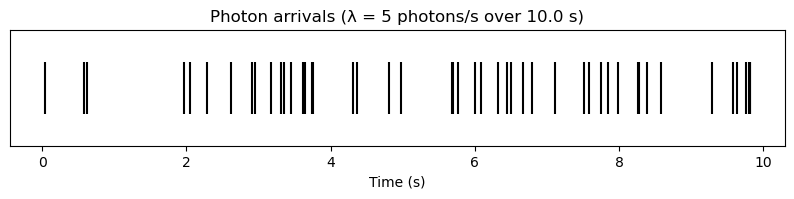

Total photons detected: 48


In [76]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
import ipywidgets as widgets
from IPython.display import display

# Simulation parameters
lambda_rate = 5  # photons per second
duration = 10.0  # seconds

# Simulate the number of photons
n_photons = np.random.poisson(lam=lambda_rate * duration)

# Draw random arrival times (uniformly distributed over [0, duration])
arrival_times = np.sort(np.random.uniform(0, duration, size=n_photons))

plt.figure(figsize=(10, 1.5))
plt.eventplot(arrival_times, colors='black', lineoffsets=0)
plt.xlabel("Time (s)")
plt.title(f"Photon arrivals (λ = {lambda_rate} photons/s over {duration} s)")
plt.yticks([])
plt.show()

print(f"Total photons detected: {n_photons}")

**Questions**
* Do the photons arrive at regular intervals?
* If you repeated this experiment, would you get the same arrival pattern? Give it a try!
* Why is it still meaningful to talk about a rate λ, even though individual events are random?

## From Time Series to Counts

Now we’ll **bin** the photon arrivals into 1-second intervals, similar to how we might bin astronomical event data to generate a light curve.


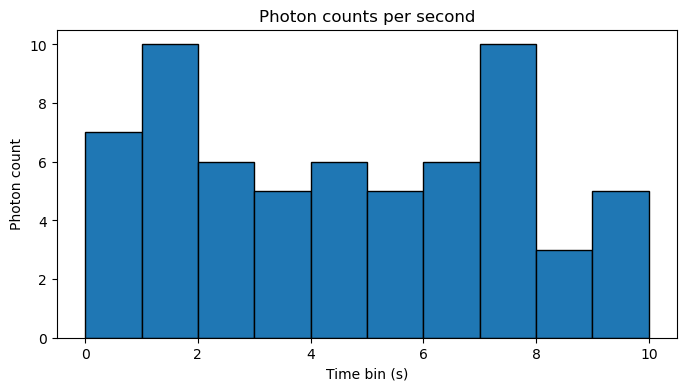

In [2]:
bin_edges = np.arange(0, duration + 1, 1)
counts, _ = np.histogram(arrival_times, bins=bin_edges)

plt.figure(figsize=(8, 4))
plt.bar(bin_edges[:-1], counts, width=1, align='edge', edgecolor='black')
plt.xlabel("Time bin (s)")
plt.ylabel("Photon count")
plt.title("Photon counts per second")
plt.show()

**Questions**
* Are all bins the same height? Why or why not?
* How could you summarize the overall behavior of this random variation?

## Building the Distribution

Let’s now repeat the experiment many times — say 1000 times — and look at the distribution of counts we might expect.


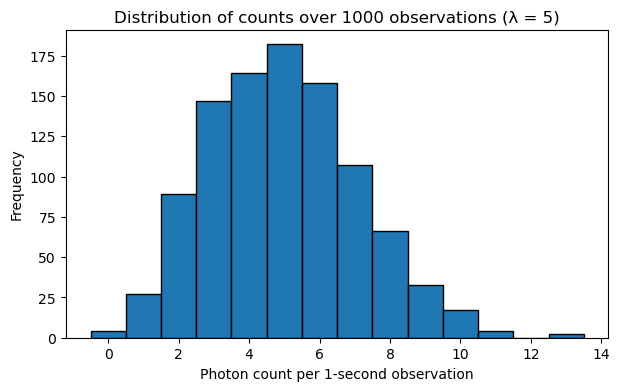

In [3]:
n_observations = 1000
duration = 1.0  # 1-second exposures
lambda_rate = 5

counts = np.random.poisson(lam=lambda_rate * duration, size=n_observations)

plt.figure(figsize=(7, 4))
plt.hist(counts, bins=np.arange(0, max(counts)+2)-0.5, edgecolor='black')
plt.xlabel("Photon count per 1-second observation")
plt.ylabel("Frequency")
plt.title(f"Distribution of counts over {n_observations} observations (λ = {lambda_rate})")
plt.show()

**Questions**
* What is the most common count value?
* Is the distribution symmetric or skewed?
* How does this relate to the random arrivals you saw earlier?

## Interactive Exploration with ipywidgets
Let’s explore how the true brightness $\lambda$ affects the distribution.
Use the slider to change $\lambda$ and see the histogram update.

In [4]:
import ipywidgets as widgets
from ipywidgets import interact

@interact(lambda_rate=widgets.FloatSlider(value=5, min=0.1, max=100, step=0.1, description='λ (rate)'))
def plot_photon_histogram(lambda_rate):
    n_observations = 1000
    counts = np.random.poisson(lam=lambda_rate, size=n_observations)
    plt.figure(figsize=(7, 4))
    plt.hist(counts, bins=np.arange(0, max(counts)+2)-0.5, edgecolor='black', color='skyblue')
    plt.xlabel("Photon count per observation")
    plt.ylabel("Frequency")
    plt.title(f"Photon count distribution (λ = {lambda_rate:.1f})")
    plt.show()

interactive(children=(FloatSlider(value=5.0, description='λ (rate)', min=0.1), Output()), _dom_classes=('widge…

**Questions**
* How does increasing $\lambda$ change the shape of the histogram?
* What happens to the relative variability (the width compared to the mean)?
* For large $\lambda$, what kind of familiar shape does the distribution resemble?

## The Poisson Probability Mass Function: Theory vs. Data

So far, we have:
- simulated photon counts in many identical measurements (e.g. time bins or pixels),
- and looked at the **histogram** of these counts.

Now we connect that empirical picture to the **theoretical model**:  
the **Poisson distribution** for the photon counts.

If the expected number of counts per measurement is \(\lambda\), then the
probability of observing exactly \(k\) counts in one measurement is

$$
P(K = k; \lambda) = \frac{e^{-\lambda} \lambda^k}{k!}, \quad k = 0, 1, 2, \dots
$$

This is called the **probability mass function (PMF)** of the Poisson distribution.

In a simulation with $N$ independent measurements:
- we can estimate this PMF empirically by the **relative frequencies** of each count value $k$,
- and we can compare these relative frequencies to the theoretical Poisson PMF.

**Exercise**:
* Change the sliders below. As you change the number of measurements, how does your empirical approximation of the Poisson distribution change?

In [98]:
def simulate_poisson_counts(lam, n_measurements, random_state=None):
    """
    Simulate n_measurements independent Poisson counts
    with mean lam.
    """
    rng = np.random.default_rng(random_state)
    return rng.poisson(lam, size=n_measurements)


def plot_empirical_vs_theoretical(lam=3.0, n_measurements=50):
    """
    Simulate Poisson counts and compare the empirical
    relative frequencies to the theoretical Poisson PMF.
    """
    # Simulate data
    counts = simulate_poisson_counts(lam, n_measurements)
    
    # Choose a sensible range of k values to display
    k_max = max(counts.max(), int(lam + 4 * np.sqrt(lam)))  # a few sigma above mean
    k_values = np.arange(0, k_max + 1)
    
    # Empirical relative frequencies
    empirical_counts = np.array([(counts == k).sum() for k in k_values])
    empirical_freq = empirical_counts / n_measurements
    
    # Theoretical Poisson PMF
    pmf = poisson.pmf(k_values, lam)
    
    # Plot
    fig, ax = plt.subplots()
    
    # Empirical as bars
    ax.bar(k_values - 0.2, empirical_freq, width=0.4,
           alpha=0.6, label="Empirical (relative frequency)")
    
    # Theoretical as points + line
    ax.plot(k_values + 0.2, pmf, "o-", label="Theoretical Poisson PMF")
    
    ax.set_xlabel("Photon count k")
    ax.set_ylabel("Probability / Relative frequency")
    ax.set_title(r"Poisson($\lambda$ = {lam:.1f}),  N = {n_measurements} measurements")
    ax.legend()
    plt.tight_layout()
    plt.show()


interact(
    plot_empirical_vs_theoretical,
    lam=FloatSlider(
        value=3.0, min=0.5, max=20.0, step=0.5,
        description="λ (mean counts)"
    ),
    n_measurements=IntSlider(
        value=20, min=5, max=1000, step=5,
        description="N measurements"
    )
);

interactive(children=(FloatSlider(value=3.0, description='λ (mean counts)', max=20.0, min=0.5, step=0.5), IntS…


## Using the Poisson Cumulative Distribution Function for X-ray Source Detection

In real X-ray images, we often measure counts in a **source region** and a nearby
**background region**.

Even if no true source is present, random fluctuations of the background can
produce apparent "hot pixels".  
To decide whether an observed count excess is significant, we ask:

> What is the probability of observing $k_\mathrm{obs}$ or more counts purely by chance,
> if the true mean background is $λ_b$?

Imagine the true mean background rate is ~5 photons/second. In a one-second observation, we have observed $k_\mathrm{obs} = 10$ photons. Discuss with a partner:
* Can you think of reasons why we might want the probability for $k_\mathrm{obs}$ *or more counts* rather than just $k_\mathrm{obs}$ counts?
* Use the slider in the Figure above to plot the empirical distribution and theoretical probability mass function. Do you think the 10 photons we detected constitute a signal from a real astronomical source? Or do you think they're just noise?



###  The Cumulative Distribution Function

The probability we need comes from the **Poisson CDF**:
$$
P(K \ge k_\text{obs}) = 1 - F(k_\text{obs}-1; \lambda_b)
$$
If this probability (p-value) is very small, the excess is unlikely to be due to
chance and we claim a **source detection**.

In [79]:
from scipy.stats import poisson

In [85]:
def show_poisson_detection(lambda_b=3.0, k_obs=8):
    k = np.arange(0, max(15, int(lambda_b * 4)))
    pmf = poisson.pmf(k, lambda_b)
    cdf = poisson.cdf(k, lambda_b)
    p_tail = 1 - poisson.cdf(k_obs - 1, lambda_b)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5), sharex=True, sharey=True)
    ax1.bar(k, pmf, alpha=0.5, label="Poisson PMF")
    ax1.step(k, cdf, where="post", color="C1", label="Cumulative (CDF)")
    ax1.axvline(k_obs, color="red", linestyle="--", label=f"k_obs = {k_obs}")
    #ax1.text(k_obs + 0.3, 0.1, f"P(K ≥ {k_obs}) = {p_tail:.3f}",
    #        color="red", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    ax1.set_xlabel("Photon count k")
    ax1.set_ylabel("Probability")
    ax1.set_title(f"Poisson model with λ_b = {lambda_b:.1f}")
    ax1.legend()

    ax2.bar(k, pmf, alpha=0.5, label="Poisson PMF")
    ax2.step(k, 1-cdf, where="post", color="C2", label="Survival function (1-CDF)")

    ax2.axvline(k_obs, color="red", linestyle="--", label=f"k_obs = {k_obs}")
    ax2.text(k_obs + 0.3, 0.1, f"P(K ≥ {k_obs}) = {p_tail:.3f}",
            color="red", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    ax2.set_xlabel("Photon count k")
    ax2.set_ylabel("Probability")
    ax2.set_title(f"Poisson model with λ_b = {lambda_b:.1f}")
    ax2.legend()

    plt.tight_layout()
    plt.show()

interact(
    show_poisson_detection,
    lambda_b=FloatSlider(value=3.0, min=0.5, max=15.0, step=0.1, description="λ_b"),
    k_obs=IntSlider(value=8, min=0, max=25, step=1, description="k_obs")
);

interactive(children=(FloatSlider(value=3.0, description='λ_b', max=15.0, min=0.5), IntSlider(value=8, descrip…

### Questions

1. Try λ_b = 5 and move k_obs from 0 to 15.
   - For which k_obs does P(K ≥ k_obs) fall below 0.05?
   - What does this mean physically?

2. If you double the background level (λ_b = 10), how does that change the
   threshold for a "significant" detection?

3. Suppose a faint source gives λ_s = 2 additional counts on top of λ_b = 3.
   - Simulate several realisations and estimate how often you'd correctly claim a detection
     at a 5% false-alarm threshold.

Here's a little helper function to help you with exercise 3:

In [88]:
def poisson_threshold(lambda_b, alpha=0.05):
    """
    Return smallest integer k such that P(K ≥ k | λ_b) ≤ alpha.
    """
    k = 0
    while (1 - poisson.cdf(k - 1, lambda_b)) > alpha:
        k += 1
    return k



In [89]:
for lam in [1, 3, 5, 10]:
    print(f"λ_b={lam:>2}:  5% threshold k ≥ {poisson_threshold(lam, 0.05)}")

λ_b= 1:  5% threshold k ≥ 4
λ_b= 3:  5% threshold k ≥ 7
λ_b= 5:  5% threshold k ≥ 10
λ_b=10:  5% threshold k ≥ 16


**Note**: We haven't really defined what significance means, or how this works more generally. Don't worry! We'll talk about this in detail in Lecture 4!

## Percentiles

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

data = np.random.poisson(20, 500)
data.sort()

@interact(p=FloatSlider(min=0, max=100, step=1, value=50))
def show_percentile(p):
    val = np.percentile(data, p)
    plt.hist(data, bins=30, color='lightgray')
    plt.axvline(val, color='red', lw=2)
    plt.title(f"{p}th percentile = {val:.2f}")
    plt.show()

interactive(children=(FloatSlider(value=50.0, description='p', step=1.0), Output()), _dom_classes=('widget-int…


## From Simulations to Real Data

Now, let’s connect our simulation to real photon arrival data.
This is a NASA NICER observation of the accreting black hole MAXI 1820+070 during its 2018 outburst. The actual observation is 2.4GB big (accreting black holes in outburst produce a *lot* of photons!), so this is a tiny piece of it.


In [36]:
import h5py
from astropy.io.misc import hdf5
import stingray

# NOTE: CHANGE THIS DIRECTORY TO WHERE YOU'VE SAVED THE DATA FILE!
datadir = "/Users/danielahuppenkothen/work/teaching/statphys_2025-2026/"

## SOLUTIONS ONLY: Data preparation

This section is here only for completeness, so that in future iterations, I can retrace how I generated the data supplied to the learners.

Data was downloaded from: https://zenodo.org/records/13149195
We only use the `data_small.hdf5` file from that repository.

In [37]:
# name of the data file
fname = "data_smaller.hdf5"

data = hdf5.read_table_hdf5(datadir + fname)
energy = data["energy"]
time = data["time"]

time = np.array(time - time[0])

Let's make a light curve to see what the data looks like:

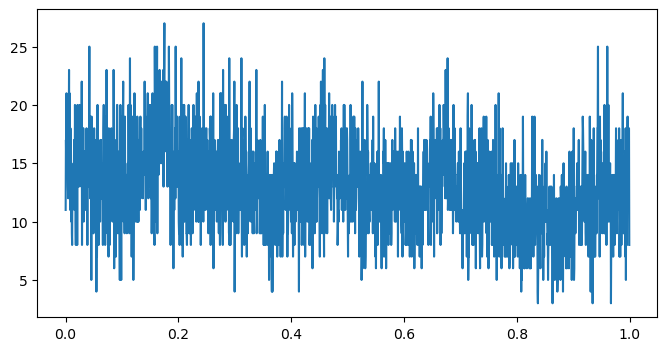

In [38]:
lc = stingray.Lightcurve.make_lightcurve(time[time < 1], dt=0.0005)

fig, ax = plt.subplots(1, 1, figsize=(8,4))

ax.plot(lc.time, lc.counts)

Let's save two versions of the data: one with just 1s of data (which we're going to assume to be approximately constant), and one that is larger, possibly for future use.

In [39]:
outname_small = "MAXI1820+070_1200120106_1s.dat"
np.savetxt(datadir + outname_small, time[time < 1])

outname_large = "MAXI1820+070_1200120106_100s.dat"
np.savetxt(datadir + outname_large, time[time < 100])


## Back to the Actual analysis of the data

Let's first load the prepared event list:

In [45]:
fname = "MAXI1820+070_1200120106_1s.dat"

arrival_times_real = np.loadtxt(datadir + fname)

In [46]:
arrival_times_real

array([0.00000000e+00, 2.12043524e-05, 3.61353159e-05, ...,
       9.99938190e-01, 9.99961376e-01, 9.99989986e-01], shape=(26083,))

This is a list of ~26000 photons, all recorded within a single second of observations from this accreting black hole. Let's plot the first 100 or so:

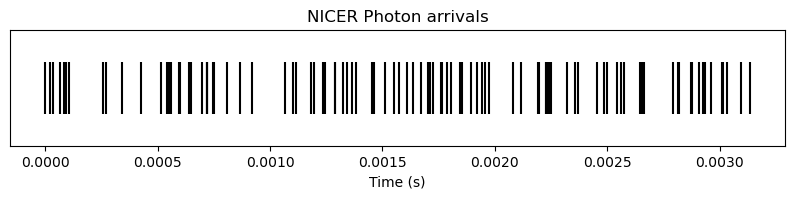

In [47]:
plt.figure(figsize=(10, 1.5))
plt.eventplot(arrival_times_real[:100], colors='black', lineoffsets=0)
plt.xlabel("Time (s)")
plt.title(f"NICER Photon arrivals")
plt.yticks([])
plt.show()


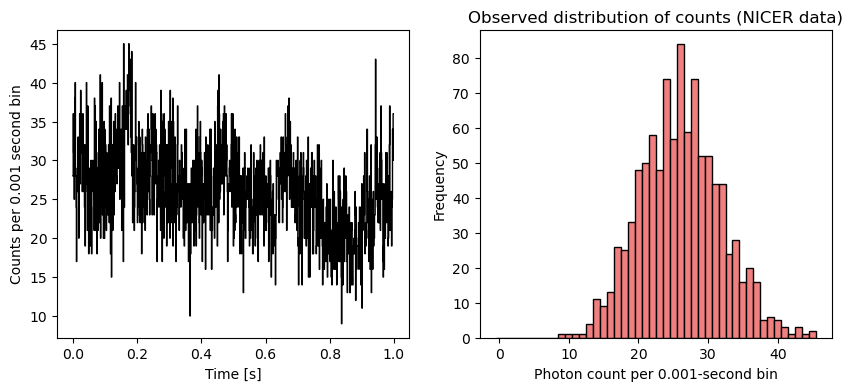

In [59]:
bin_edges = np.arange(arrival_times_real.min(), arrival_times_real.max(), 0.001)
counts_real, _ = np.histogram(arrival_times_real, bins=bin_edges)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(bin_edges[:-1], counts_real, lw=1, color="black", ds="steps-mid")
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Counts per 0.001 second bin")


ax2.hist(counts_real, bins=np.arange(0, max(counts_real)+2)-0.5, edgecolor='black', color='lightcoral')
ax2.set_xlabel("Photon count per 0.001-second bin")
ax2.set_ylabel("Frequency")
ax2.set_title("Observed distribution of counts (NICER data)")
plt.show()

**Exercises** 
* *Do we have a source in the data?* The NICER background rate is generally low, but also highly variable, due to cosmic rays, space weather, particles from the environment, and the South Atlantic Anomaly. Here, let's assume that the background rate for this observation was 15 counts per 0.001 second bin. Do you think we've detected a source? At what significance?
* We often want to know what the true flux of the source is, since that can tell us how much energy the source emitted isotropically. Think about how you could estimate the true underlying count rate (a quantity you can convert into the flux if you know some of the details of the instrument) from the data. What (simple!) quantity or quantities would you calculate?
* Below, I've given you a simple, visual way of parameter estimation by comparing the observed histogram of the flux to simulated histograms with different count rates. Move the slider to roughly estimate what you think the true count rate might be. Does it agree with whatever metric you calculated above?



In [ ]:
## Add your code to compute the true count rate here

In [60]:
@interact(lambda_guess=widgets.FloatSlider(value=5, min=1, max=30, step=0.5, description='λ (guess)'))
def compare_to_real(lambda_guess):
    simulated = np.random.poisson(lam=lambda_guess, size=len(counts_real))
    plt.figure(figsize=(7, 4))
    plt.hist(counts_real, bins=np.arange(0, max(counts_real)+2)-0.5, alpha=0.6, label="Real data")
    plt.hist(simulated, bins=np.arange(0, max(simulated)+2)-0.5, alpha=0.6, label="Simulated (λ guess)")
    plt.xlabel("Photon count per bin")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title("Compare simulated and observed count distributions")
    plt.show()

interactive(children=(FloatSlider(value=5.0, description='λ (guess)', max=30.0, min=1.0, step=0.5), Output()),…

**Questions**:
* What approximate λ value best matches the observed distribution?
* How does your “eyeballed” inference compare to the average count per bin in the real data?
* Why might the match not be perfect? (Consider variability, background, instrumental effects.)

In [61]:
np.mean(counts_real)

np.float64(26.084084084084083)

## Reflection and Connection to Inference
You’ve just performed a primitive form of inference: you adjusted a model parameter ($\lambda$) until its predicted distribution matched the data.

Later in the course, we’ll formalize this process mathematically:
* Quantifying “goodness of fit” with likelihoods
* Exploring uncertainty using posterior distributions

But conceptually, the key ideas are already here:
* Data are realizations of random processes
* Models describe the expected distribution of those data
* Inference is the process of finding model parameters that best explain what we observed